In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from biom import Table, load_table
from biom.util import biom_open
from scipy.optimize import curve_fit
from scipy.stats import linregress
from skbio.stats.composition import closure

In [2]:
INPUT_DIR = Path("input_files")
OUTDIR = Path("output_files")
OUTDIR.mkdir(parents=True, exist_ok=True)

RAW_BIOM_FILE = OUTDIR / "birdman_feature_table_with_taxonomy.biom"
FILTERED_BIOM_FILE = OUTDIR / "digesta_filtered_table_with_taxonomy.biom"
FILTERED_BIOM_WITH_METADATA_FILE = OUTDIR / "digesta_filtered_table_with_sample_metadata.biom"
MODEL_METADATA_FILE = OUTDIR / "metadata_model_used_for_BIRDMAn.tsv"
DISPERSION_PRIOR_FILE = OUTDIR / "digesta_dispersion_and_inv_disp_prior.tsv"
STAN_FILE = OUTDIR / "negative_binomial_model.stan"
INFERENCE_CLR_FILE = OUTDIR / "inference.nc"
INFERENCE_LABELED_FILE = OUTDIR / "inference_ASV_annotated.nc"
LOO_COMPARISON_FILE = OUTDIR / "loo_model_comparison.tsv"

In [3]:
# Create BIOM table with taxonomy
# 1. Load OTU table (features x samples)
counts = pd.read_csv(INPUT_DIR / "birdman_otu_table.tsv", sep="\t", index_col=0)

# 2. Load full taxonomy table (rows = features/ASVs)
taxonomy = pd.read_csv(INPUT_DIR / "birdman_taxonomy.tsv", sep="\t", index_col=0)

# If 'ASV' is a column (not the index), drop it
if "ASV" in taxonomy.columns:
    taxonomy = taxonomy.drop(columns=["ASV"])

# 3. Make sure we have a single semicolon-joined taxonomy string
if "Taxonomy" not in taxonomy.columns:
    # adapt col slice if different number of ranks
    taxonomy["Taxonomy"] = taxonomy.iloc[:, 0:7].apply(
        lambda x: "; ".join(str(i) for i in x if pd.notnull(i)),
        axis=1
    )
# Keep only Taxonomy column
taxonomy = taxonomy[["Taxonomy"]]

# 4. Align taxonomy with count table by ASV IDs
taxonomy = taxonomy.reindex(counts.index)

# 5. Build observation metadata in BIOM-style:
#    {"taxonomy": ["k__Bacteria", "p__Firmicutes", ...]}
observation_metadata = []
for asv, row in taxonomy.iterrows():
    tax_str = row["Taxonomy"]

    if isinstance(tax_str, str) and tax_str.strip():
        tax_list = [t.strip() for t in tax_str.split(";") if t.strip()]
        observation_metadata.append({"taxonomy": tax_list})
    else:
        # no taxonomy available for this ASV
        observation_metadata.append(None)

# 6. Create BIOM table
biom_table = Table(
    counts.values,
    observation_ids=counts.index.astype(str),
    sample_ids=counts.columns.astype(str),
    observation_metadata=observation_metadata
)

# Save BIOM
with open(RAW_BIOM_FILE, "w") as f:
    f.write(biom_table.to_json("biom_table"))

print(f"Saved BIOM table: {RAW_BIOM_FILE.resolve()}")
print("Shape (features × samples):", biom_table.shape)


Saved BIOM table: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/birdman_feature_table_with_taxonomy.biom
Shape (features × samples): (3261, 358)


In [4]:
# Load the BIOM table just written above
# sanity check that the file is valid and taxonomy metadata are retained).
table = load_table(RAW_BIOM_FILE)

# Summarize table shape and IDs
print("✅ Format OK!")
print("Shape (features × samples):", table.shape)
print("First 5 samples:", table.ids(axis='sample')[:5])
print("First 5 features:", table.ids(axis='observation')[:5])

# Extract taxonomy metadata if available
obs_md = table.metadata(axis='observation')

if obs_md and "taxonomy" in obs_md[0]:
    print("✅ Taxonomy metadata found.")

    # Extract taxonomy into strings
    taxonomy_list = [md["taxonomy"] for md in obs_md]
    taxonomy_strs = ["; ".join(t) if isinstance(t, list) else str(t) for t in taxonomy_list]

    taxonomy_df = pd.DataFrame({
        "FeatureID": table.ids(axis='observation'),
        "Taxonomy": taxonomy_strs
    }).set_index("FeatureID")

    # Now summarize taxonomy
    print("\nTop 10 most common taxonomic assignments:")
    print(taxonomy_df["Taxonomy"].value_counts().head(10))

else:
    print("⚠️ No taxonomy metadata found.")

✅ Format OK!
Shape (features × samples): (3261, 358)
First 5 samples: ['MicrobE_1_D_P1' 'MicrobE_2_D_P1' 'MicrobE_3_D_P1' 'MicrobE_4_D_P1'
 'MicrobE_5_D_P1']
First 5 features: ['ASV_1' 'ASV_2' 'ASV_3' 'ASV_4' 'ASV_5']
✅ Taxonomy metadata found.

Top 10 most common taxonomic assignments:
Taxonomy
k__Bacteria; p__Pseudomonadota; c__Gammaproteobacteria; o__Pseudomonadales; f__Pseudomonadaceae; g__Pseudomonas; s__     88
k__Bacteria; p__Pseudomonadota; c__Gammaproteobacteria; o__Pseudomonadales; f__Moraxellaceae; g__Acinetobacter; s__      71
k__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__Flavobacterium; s__          69
k__Bacteria; p__Actinomycetota; c__Actinobacteria; o__Mycobacteriales; f__Corynebacteriaceae; g__Corynebacterium; s__    58
k__Bacteria; p__Pseudomonadota; c__Gammaproteobacteria; o__Enterobacterales; f__Vibrionaceae; g__Photobacterium; s__     54
k__Bacteria; p__Bacillota; c__Bacilli; o__Mycoplasmatales; f__Mycoplasmataceae; g__

In [5]:
# Load sample metadata table
metadata = pd.read_csv(INPUT_DIR / "birdman_sample_metadata.tsv", sep="\t", index_col=0)
metadata.head()

,SampleID,sample_number,rearing_tank,sample_type,Diet,Day,sample_type_diet_day,sample_type_diet,PLSDA_Y,DNA_extraction_batch,grinding_method,PCR1_batch,PGTB_batch,Plasma_Glucose,HSI,Body_Weight,sampleID_STPN2309,Plasma_L-Lactate,Plasma_D-Lactate
Unnamed: 0,,,,,,,,,,,,,,,,,,,
MicrobE_1_D_P1,MicrobE_1_D_P1,1.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,F,Precellys,PCR1_1,P1,0.867267,0.895954,69.2,S_017,3.262599,0.038986
MicrobE_107_D_P2,MicrobE_107_D_P2,107.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,C,TissueLyser,PCR1_3,P2,0.682533,1.268437,67.8,S_023,2.552836,0.014270
MicrobE_109_D_P2,MicrobE_109_D_P2,109.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,D,Precellys,PCR1_3,P2,0.824363,0.796020,80.4,S_021,1.458673,0.020578
MicrobE_119_D_P2,MicrobE_119_D_P2,119.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,F,Precellys,PCR1_3,P2,0.595514,0.897598,79.1,S_007,NaN,0.006162
MicrobE_142_D_P2,MicrobE_142_D_P2,142.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,A,TissueLyser,PCR1_4,P2,0.615200,1.073620,65.2,S_005,1.866123,0.016240


In [6]:
print(set(table.ids(axis='sample')) <= set(metadata.index))

True


In [7]:
# Subset metadata where sample_type == "Digesta" and Diet is either "NC" or "HC"
metadata_model = metadata[
    (metadata["sample_type"] == "Digesta") &
    (metadata["Diet"].isin(["NC", "HC"]))
].copy()
# Check the result
print(metadata_model.shape)
metadata_model.head()

(165, 19)


,SampleID,sample_number,rearing_tank,sample_type,Diet,Day,sample_type_diet_day,sample_type_diet,PLSDA_Y,DNA_extraction_batch,grinding_method,PCR1_batch,PGTB_batch,Plasma_Glucose,HSI,Body_Weight,sampleID_STPN2309,Plasma_L-Lactate,Plasma_D-Lactate
Unnamed: 0,,,,,,,,,,,,,,,,,,,
MicrobE_118_D_P2,MicrobE_118_D_P2,118.0,K1,Digesta,HC,day_01,Digesta_HC_day1,Digesta_HC,Digesta_HC_G1,G,Precellys,PCR1_3,P2,2.844300,0.881579,76.0,S_049,2.536151,0.038088
MicrobE_122_D_P2,MicrobE_122_D_P2,122.0,K3,Digesta,HC,day_01,Digesta_HC_day1,Digesta_HC,Digesta_HC_G1,H,Precellys,PCR1_3,P2,1.056100,1.584634,83.3,S_065,2.096774,0.038313
MicrobE_138_D_P2,MicrobE_138_D_P2,138.0,K3,Digesta,HC,day_01,Digesta_HC_day1,Digesta_HC,Digesta_HC_G1,D,Precellys,PCR1_3,P2,1.299367,1.281139,84.3,S_067,2.500952,0.035702
MicrobE_141_D_P2,MicrobE_141_D_P2,141.0,K1,Digesta,HC,day_01,Digesta_HC_day1,Digesta_HC,Digesta_HC_G1,F,Precellys,PCR1_3,P2,1.364600,1.114206,71.8,S_055,3.559301,0.042535
MicrobE_15_D_P1,MicrobE_15_D_P1,15.0,K3,Digesta,HC,day_01,Digesta_HC_day1,Digesta_HC,Digesta_HC_G1,H,Precellys,PCR1_1,P1,1.177261,2.084746,59.0,S_069,2.948778,0.025473


In [8]:
# Convert to categorical with NC as the reference level
metadata_model["Diet"] = pd.Categorical(
    metadata_model["Diet"],
    categories=["NC", "HC"],  # Explicit ref level order
    ordered=True
)

# Now you can inspect the levels
print("Diet levels:", metadata_model["Diet"].cat.categories)
print("Diet codes mapping:", dict(enumerate(metadata_model["Diet"].cat.categories)))

Diet levels: Index(['NC', 'HC'], dtype='object')
Diet codes mapping: {0: 'NC', 1: 'HC'}


In [9]:
# Convert BIOM table to DataFrame and filter samples -
raw_tbl_df = table.to_dataframe()

# Step 1: Keep only the samples present in your filtered metadata
samps_to_keep = sorted(list(set(raw_tbl_df.columns).intersection(metadata_model.index)))
filt_tbl_df = raw_tbl_df.loc[:, samps_to_keep]

# Filter ASVs present in at least 20% of retained samples
prevalence_prop = 0.20
min_prevalence = int(np.ceil(prevalence_prop * filt_tbl_df.shape[1]))

# Keep your original prevalence calculation
prev = filt_tbl_df.clip(upper=1).sum(axis=1)

filt_tbl_df = filt_tbl_df.loc[
    prev >= min_prevalence,
    :
]

filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns,
    observation_ids=filt_tbl_df.index
)

print(f"Minimum prevalence: {min_prevalence} samples ({prevalence_prop:.0%})")
print(f"Maximum observed prevalence: {prev.max()}")
print("Shape (features × samples):", filt_tbl.shape)

Minimum prevalence: 33 samples (20%)
Maximum observed prevalence: 165.0
Shape (features × samples): (140, 165)


In [10]:
# Calculate mean and variance per ASV
means = filt_tbl_df.astype(float).mean(axis=1)
print(means)

ASV_48      172.545455
ASV_85       23.733333
ASV_86       44.303030
ASV_186     287.763636
ASV_207      48.187879
               ...    
ASV_3155      9.842424
ASV_3184     20.557576
ASV_3212     49.163636
ASV_3234    194.181818
ASV_3258    262.430303
Length: 140, dtype: float64


In [11]:
variances = filt_tbl_df.astype(float).var(axis=1, ddof=1)
print(variances)

ASV_48      3.001218e+05
ASV_85      1.514367e+03
ASV_86      7.595712e+03
ASV_186     9.369451e+06
ASV_207     3.574437e+04
                ...     
ASV_3155    3.891092e+02
ASV_3184    3.942895e+03
ASV_3212    8.426125e+03
ASV_3234    1.232906e+05
ASV_3258    2.688888e+05
Length: 140, dtype: float64


In [12]:
# Calculate raw dispersion
raw_dispersion = (variances - means) / (means ** 2)
print(raw_dispersion)

ASV_48       10.074901
ASV_85        2.646388
ASV_86        3.847345
ASV_186     113.143332
ASV_207      15.372560
               ...    
ASV_3155      3.915080
ASV_3184      9.281135
ASV_3212      3.465760
ASV_3234      3.264586
ASV_3258      3.900503
Length: 140, dtype: float64


In [13]:
# Fit dispersion trend curve before the mean-abundance threshold
def disp_trend(mu, a0, a1):
    return a0 + a1 / mu

valid = (means > 0) & (raw_dispersion > 0)
popt, pcov = curve_fit(
    disp_trend,
    means[valid],
    raw_dispersion[valid],
    maxfev=10000
)
print(f"Pre-threshold params: a0 = {popt[0]:.4f}, a1 = {popt[1]:.4f}")

pre_threshold_dispersion = disp_trend(means, *popt)
if (pre_threshold_dispersion <= 0).any() or (~np.isfinite(pre_threshold_dispersion)).any():
    print("Warning: the pre-threshold trend has non-positive/invalid values; it is exploratory only.")
else:
    pre_threshold_inv_disp = 1.0 / pre_threshold_dispersion
    print(pre_threshold_inv_disp.head())

Pre-threshold params: a0 = 9.6884, a1 = -1.3161
ASV_48     0.103298
ASV_85     0.103810
ASV_86     0.103534
ASV_186    0.103265
ASV_207    0.103508
dtype: float64


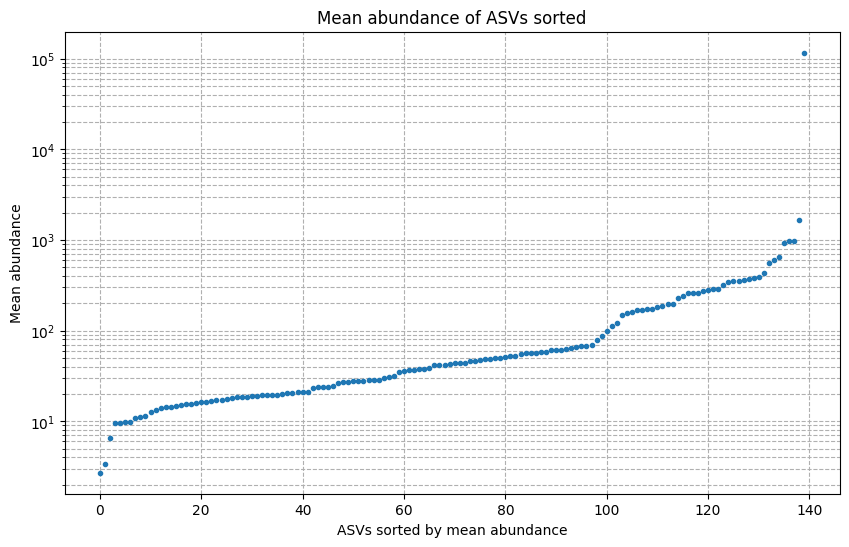

In [14]:
# --- 5. Visualize ASV mean abundances ---
sorted_means = means.sort_values()

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sorted_means)), sorted_means, marker='.', linestyle='none')
plt.xlabel("ASVs sorted by mean abundance")
plt.ylabel("Mean abundance")
plt.title("Mean abundance of ASVs sorted")
plt.yscale("log")
plt.grid(True, which='both', linestyle='--')
plt.show()

In [15]:
# Try different filtering thresholds
thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 50]
for t in thresholds:
    filtered = means[means > t]
    print(f"Threshold > {t}: {len(filtered)} ASVs retained")

Threshold > 1: 140 ASVs retained
Threshold > 2: 140 ASVs retained
Threshold > 3: 139 ASVs retained
Threshold > 4: 138 ASVs retained
Threshold > 5: 138 ASVs retained
Threshold > 6: 138 ASVs retained
Threshold > 7: 137 ASVs retained
Threshold > 8: 137 ASVs retained
Threshold > 9: 137 ASVs retained
Threshold > 10: 133 ASVs retained
Threshold > 15: 123 ASVs retained
Threshold > 20: 104 ASVs retained
Threshold > 50: 61 ASVs retained


In [16]:
# Choose a threshold and filter ASVs
threshold = 1.0
filtered_asvs = means[means > threshold]
print(f"Number of ASVs after filtering: {len(filtered_asvs)}")

# Filter filt_tbl_df to keep only ASVs above threshold
filt_tbl_df = filt_tbl_df.loc[filtered_asvs.index]

Number of ASVs after filtering: 140


In [17]:
means_f = filt_tbl_df.astype(float).mean(axis=1)
vars_f = filt_tbl_df.astype(float).var(axis=1, ddof=1)

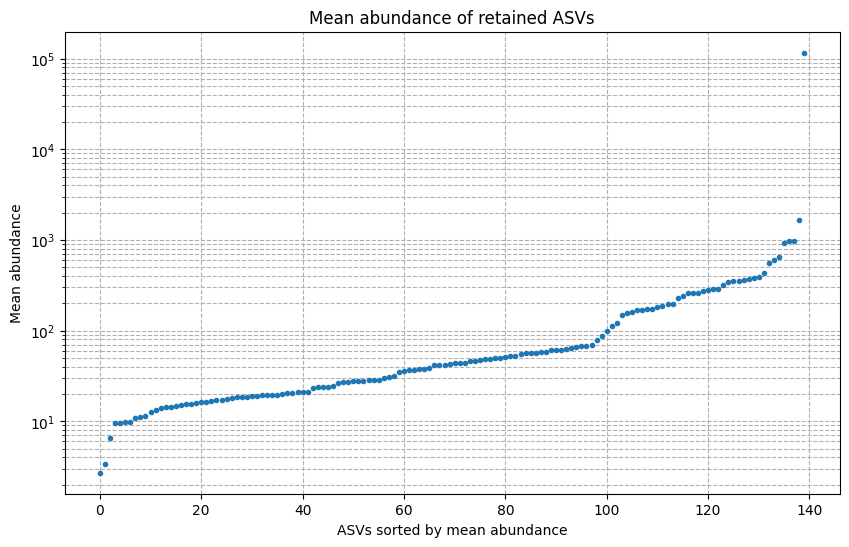

In [18]:
# Keep this second plot: it shows the retained distribution after changing `threshold`.
sorted_means = means_f.sort_values().to_numpy()

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sorted_means)), sorted_means, marker='.', linestyle='none')
plt.xlabel("ASVs sorted by mean abundance")
plt.ylabel("Mean abundance")
plt.title("Mean abundance of retained ASVs")
plt.yscale("log")
plt.grid(True, which='both', linestyle='--')
plt.show()

In [19]:
print(sorted_means[:10])   # smallest means
print(sorted_means[-10:])  # largest means
print(np.median(sorted_means))

[ 2.7030303   3.35151515  6.47272727  9.45454545  9.56363636  9.84242424
  9.85454545 10.95757576 11.12727273 11.36363636]
[   388.26666667    437.12121212    549.95151515    607.61212121
    646.0969697     935.82424242    974.23636364    976.63030303
   1661.51515152 116343.40606061]
43.28484848484848


In [20]:
raw_disp_f = (vars_f - means_f) / np.maximum(means_f**2, 1e-12)

In [21]:
# Fit the final DESeq2-style dispersion trend on the retained ASVs.
valid_f = (means_f > 0) & (raw_disp_f > 0)
popt_f, _ = curve_fit(
    disp_trend,
    means_f[valid_f].values,
    raw_disp_f[valid_f].values,
    maxfev=10000
)
a0_f, a1_f = popt_f
print(f"Filtered params: a0 = {a0_f:.4f}, a1 = {a1_f:.4f}")

Filtered params: a0 = 9.6884, a1 = -1.3161


In [22]:
# Final NB2 dispersion alpha and its inverse phi used by Stan.
# In neg_binomial_2_log(..., phi), Stan's second argument is phi = 1 / alpha.
smoothed_dispersion_f = a0_f + a1_f / means_f

bad_dispersion = (~np.isfinite(smoothed_dispersion_f)) | (smoothed_dispersion_f <= 0)
if bad_dispersion.any():
    bad_features = smoothed_dispersion_f.index[bad_dispersion].tolist()
    raise ValueError(
        "Final smoothed dispersion has non-positive/invalid values for "
        f"{len(bad_features)} retained ASVs. Examples: {bad_features[:10]}"
    )

inv_disp_init = 1.0 / smoothed_dispersion_f
print(inv_disp_init)

ASV_48      0.103298
ASV_85      0.103810
ASV_86      0.103534
ASV_186     0.103265
ASV_207     0.103508
              ...   
ASV_3155    0.104661
ASV_3184    0.103903
ASV_3212    0.103502
ASV_3234    0.103289
ASV_3258    0.103270
Length: 140, dtype: float64


In [23]:
# Keep taxonomy metadata for exactly the filtered ASVs, in exactly their final order.
obs_md = table.metadata(axis="observation")
tax_metadata_dict = {
    feature_id: metadata
    for feature_id, metadata in zip(table.ids(axis="observation"), obs_md)
}

filtered_feature_ids = filt_tbl_df.index.tolist()
filtered_tax_metadata = [tax_metadata_dict[feature_id] for feature_id in filtered_feature_ids]

filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns.tolist(),
    observation_ids=filtered_feature_ids,
    observation_metadata=filtered_tax_metadata
)
print("Shape (features × samples):", filt_tbl.shape)

Shape (features × samples): (140, 165)


In [24]:
import numpy as np
import pandas as pd

counts = np.asarray(filt_tbl.matrix_data.todense())  # ASVs × samples
asv_ids = np.asarray(filt_tbl.ids(axis="observation"))

lib_size = counts.sum(axis=0)
rel_abund = counts / lib_size

stats = pd.DataFrame({
    "ASV": asv_ids,
    "prevalence_pct": 100 * (counts > 0).mean(axis=1),
    "median_count": np.median(counts, axis=1),
    "mean_rel_abund": rel_abund.mean(axis=1),
    "sd_rel_abund": rel_abund.std(axis=1),
})

stats["cv_rel_abund"] = (
    stats["sd_rel_abund"] / stats["mean_rel_abund"]
)

candidates = (
    stats
    .query("prevalence_pct >= 90 and median_count > 0")
    .sort_values(
        ["prevalence_pct", "cv_rel_abund", "mean_rel_abund"],
        ascending=[False, True, False]
    )
)

display(candidates.head(10))

,ASV,prevalence_pct,median_count,mean_rel_abund,sd_rel_abund,cv_rel_abund
67,ASV_1846,100.000000,118807.0,0.857177,0.136705,0.159483
126,ASV_2988,100.000000,669.0,0.007550,0.007979,1.056896
31,ASV_967,100.000000,249.0,0.003370,0.004753,1.410519
74,ASV_1954,99.393939,236.0,0.002738,0.002950,1.077474
47,ASV_1464,99.393939,314.0,0.004717,0.007466,1.582913
69,ASV_1907,99.393939,863.0,0.012663,0.022023,1.739105
95,ASV_2334,98.787879,193.0,0.001435,0.000487,0.339303
53,ASV_1587,98.787879,222.0,0.001649,0.000562,0.340664
49,ASV_1517,98.787879,237.0,0.001763,0.000641,0.363785
129,ASV_3022,98.787879,567.0,0.007699,0.009831,1.277037


In [25]:
# Choose the ALR reference ASV: it must be first in the BIOM observation order
reference_asv = "ASV_1846"

if reference_asv not in filt_tbl_df.index:
    raise ValueError(
        f"{reference_asv} is not present in the filtered ASV table."
    )

# Put the chosen reference first; retain the existing order for every other ASV
filtered_feature_ids = (
    [reference_asv] +
    [asv for asv in filt_tbl_df.index if asv != reference_asv]
)

# Reorder count table rows to match the intended ALR reference/order
filt_tbl_df = filt_tbl_df.loc[filtered_feature_ids]

# Keep taxonomy metadata aligned with the reordered ASVs
obs_md = table.metadata(axis="observation")
tax_metadata_dict = {
    feature_id: metadata
    for feature_id, metadata in zip(table.ids(axis="observation"), obs_md)
}

filtered_tax_metadata = [
    tax_metadata_dict[feature_id]
    for feature_id in filtered_feature_ids
]

# Construct filtered BIOM table: features × samples
filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns.tolist(),
    observation_ids=filtered_feature_ids,
    observation_metadata=filtered_tax_metadata
)

assert filt_tbl.ids(axis="observation")[0] == reference_asv
assert filt_tbl.shape == filt_tbl_df.shape

print("Shape (features × samples):", filt_tbl.shape)
print("ALR reference ASV:", filt_tbl.ids(axis="observation")[0])

Shape (features × samples): (140, 165)
ALR reference ASV: ASV_1846


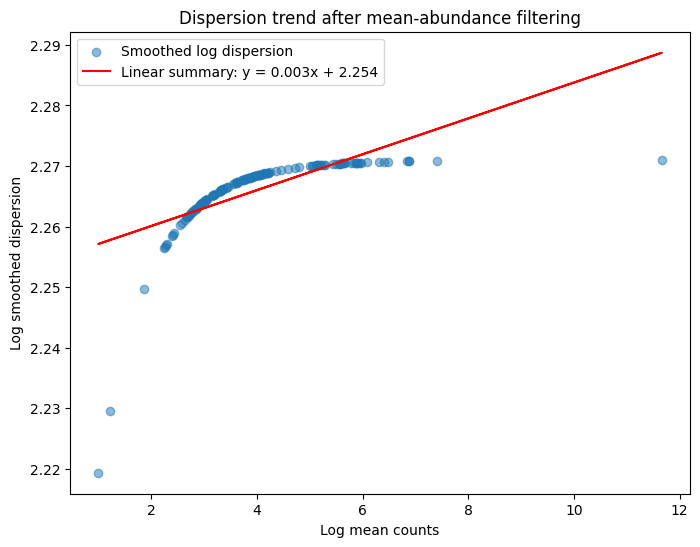

In [26]:
# Exploratory diagnostic retained from the original notebook.
log_means = np.log(means_f)
log_disp = np.log(smoothed_dispersion_f)

slope, intercept, r_value, p_value, std_err = linregress(log_means, log_disp)

plt.figure(figsize=(8, 6))
plt.scatter(log_means, log_disp, alpha=0.5, label="Smoothed log dispersion")
plt.plot(
    log_means,
    intercept + slope * log_means,
    color="red",
    label=f"Linear summary: y = {slope:.3f}x + {intercept:.3f}"
)
plt.xlabel("Log mean counts")
plt.ylabel("Log smoothed dispersion")
plt.title("Dispersion trend after mean-abundance filtering")
plt.legend()
plt.show()


Empirical mean (for prior): -5.132770022086248
Empirical std  (for prior): 1.2463334898021756


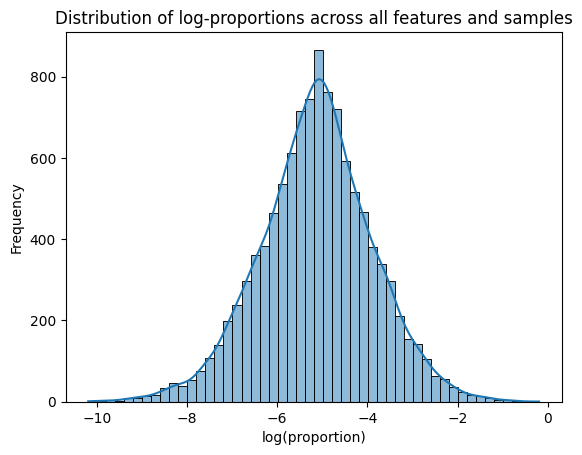

In [27]:
# pulling out any random amplicon biom table and visualizing the stats
# Namely, we can look at all of the non-zero counts, compute their log proportions and visualize the distribution
# Convert to dense NumPy array
mat = np.array(filt_tbl.matrix_data.todense())

# Apply closure to convert counts to proportions
prop_mat = closure(mat)  # Each row sums to 1

# Take the log of the proportions (masking zeros automatically)
log_prop = np.ma.log(prop_mat)  # log proportions

# Flatten and remove masked (zero) values
data = log_prop.ravel()
data = data[~data.mask]

# View stats of log-proportions
print("Empirical mean (for prior):", data.mean())
print("Empirical std  (for prior):", data.std())

# Visualize the distribution
sns.histplot(data, bins=50, kde=True)
plt.title("Distribution of log-proportions across all features and samples")
plt.xlabel("log(proportion)")
plt.ylabel("Frequency")
plt.show()

In [28]:
# We found similar results (see https://github.com/flatironinstitute/q2-matchmaker/issues/24), so we will set the same values for the model

In [29]:
with biom_open(FILTERED_BIOM_FILE, "w") as f:
    filt_tbl.to_hdf5(f, "filtered digesta table with taxonomy")

print(f"Saved filtered BIOM table: {FILTERED_BIOM_FILE.resolve()}")

Saved filtered BIOM table: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/digesta_filtered_table_with_taxonomy.biom


In [30]:
print("ASV table samples:", filt_tbl_df.shape[1])
print("Metadata samples:", metadata_model.shape[0])

print("Samples in ASV table missing from metadata:")
print(set(filt_tbl_df.columns) - set(metadata_model.index))

print("Metadata samples missing from ASV table:")
print(set(metadata_model.index) - set(filt_tbl_df.columns))


ASV table samples: 165
Metadata samples: 165
Samples in ASV table missing from metadata:
set()
Metadata samples missing from ASV table:
set()


In [31]:
metadata_model = metadata_model.loc[filt_tbl_df.columns]

assert list(metadata_model.index) == list(filt_tbl_df.columns)

print("Metadata correctly matched to ASV table.")

Metadata correctly matched to ASV table.


In [32]:
metadata_model.to_csv(
    MODEL_METADATA_FILE,
    sep="\t",
    index=True
)
print(f"Saved model metadata: {MODEL_METADATA_FILE.resolve()}")


Saved model metadata: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/metadata_model_used_for_BIRDMAn.tsv


In [33]:
sample_metadata = metadata_model.to_dict(orient="records")

filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns.tolist(),
    observation_ids=filt_tbl_df.index.tolist(),
    observation_metadata=filtered_tax_metadata,
    sample_metadata=sample_metadata
)

with biom_open(FILTERED_BIOM_WITH_METADATA_FILE, "w") as f:
    filt_tbl.to_hdf5(f, "filtered digesta table with taxonomy and sample metadata")

print(f"Saved filtered BIOM table with sample metadata: {FILTERED_BIOM_WITH_METADATA_FILE.resolve()}")

Saved filtered BIOM table with sample metadata: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/digesta_filtered_table_with_sample_metadata.biom


In [34]:
bt = load_table(FILTERED_BIOM_WITH_METADATA_FILE)

print(bt.shape)

print("First ASV metadata:")
print(bt.metadata(bt.ids(axis="observation")[0], axis="observation"))

print("First sample metadata:")
print(bt.metadata(bt.ids(axis="sample")[0], axis="sample"))

(140, 165)
First ASV metadata:
defaultdict(<function Table._cast_metadata.<locals>.cast_metadata.<locals>.<lambda> at 0x7f2010e653a0>, {'taxonomy': ['k__Bacteria', 'p__Bacillota', 'c__Bacilli', 'o__Mycoplasmatales', 'f__Mycoplasmataceae', 'g__Malacoplasma', 's__']})
First sample metadata:
defaultdict(<function Table._cast_metadata.<locals>.cast_metadata.<locals>.<lambda> at 0x7f2010ff9300>, {'Body_Weight': np.float64(138.9), 'DNA_extraction_batch': 'C', 'Day': 'day_22', 'Diet': 'NC', 'HSI': np.float64(1.137508999), 'PCR1_batch': 'PCR1_3', 'PGTB_batch': 'P2', 'PLSDA_Y': 'Digesta_NC_G2', 'Plasma_D-Lactate': np.float64(0.012133795), 'Plasma_Glucose': np.float64(0.891466667), 'Plasma_L-Lactate': np.float64(3.23853211), 'SampleID': 'MicrobE_100_D_P2', 'grinding_method': 'TissueLyser', 'rearing_tank': 'J4', 'sampleID_STPN2309': 'S_315', 'sample_number': np.float64(100.0), 'sample_type': 'Digesta', 'sample_type_diet': 'Digesta_NC', 'sample_type_diet_day': 'Digesta_NC_day22'})


In [43]:
# Save the Stan code to a file. `nb_model.compile_model()` below performs compilation.
stan_code = """
data {
  int<lower=1> N;                    // number of samples
  int<lower=2> D;                    // number of features
  real A;                            // intercept prior mean
  int<lower=1> p;                    // number of covariates
  vector[N] depth;                   // log sequencing depths
  matrix[N, p] x;                    // covariate matrix
  array[N, D] int<lower=0> y;        // observed counts

  real<lower=0> B_p;                 // slope prior SD
  real<lower=0> beta_0_sd;           // intercept prior SD

  // Prior centre for NB2 precision phi = 1 / alpha
  vector<lower=1e-8>[D] inv_disp_prior;
  real<lower=0> inv_disp_sd;
}

parameters {
  row_vector[D - 1] beta_0;
  matrix[p - 1, D - 1] beta_x;
  vector<lower=1e-8>[D] inv_disp;
}

transformed parameters {
  matrix[p, D - 1] beta_var = append_row(beta_0, beta_x);
  matrix[N, D - 1] lam;
  matrix[N, D] lam_clr;

  // Linear predictor for the D - 1 non-reference ASVs
  lam = x * beta_var;

  // Insert zero ALR coordinate for the first/reference ASV
  lam_clr = append_col(
    to_vector(rep_array(0, N)),
    lam
  );
}

model {
  // Intercept prior
  beta_0 ~ normal(A, beta_0_sd);

  // Diet, day, and diet × day effects
  to_vector(beta_x) ~ normal(0, B_p);

  // Feature-specific empirical prior for NB2 precision phi
  inv_disp ~ lognormal(log(inv_disp_prior), inv_disp_sd);

  // Apply sequencing-depth offset to ALL D ASVs,
  // including the first/reference ASV
  for (n in 1:N) {
    for (i in 1:D) {
      target += neg_binomial_2_log_lpmf(
        y[n, i] | lam_clr[n, i] + depth[n], inv_disp[i]
      );
    }
  }
}

generated quantities {
  array[N, D] int y_predict;
  array[N, D] real log_lhood;

  for (n in 1:N) {
    for (i in 1:D) {
      real eta = lam_clr[n, i] + depth[n];
      real safe_eta = fmin(eta, 13.8);

      y_predict[n, i] =
        neg_binomial_2_log_rng(safe_eta, inv_disp[i]);

      log_lhood[n, i] =
        neg_binomial_2_log_lpmf(
          y[n, i] | eta, inv_disp[i]
        );
    }
  }
}
"""

stan_filename = str(STAN_FILE)

with open(stan_filename, "w", encoding="utf-8") as f:
    f.write(stan_code)

print(f"Stan model saved to: {STAN_FILE.resolve()}")

Stan model saved to: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/negative_binomial_model.stan


In [44]:
import birdman
nb_model = birdman.TableModel(
    table=filt_tbl,
    model_path=stan_filename
)

In [45]:
# Step 2: Create the regression with your formula and metadata
nb_model.create_regression(
    metadata=metadata_model,  # your sample metadata
    formula="Diet * Day"
)

In [46]:
# Align the final inverse-dispersion vector to BIRDMAn's feature order.
# `inv_disp_init` is Stan's NB2 precision phi = 1 / alpha, not alpha itself.
inv_disp_prior = inv_disp_init.reindex(nb_model.feature_names)

if inv_disp_prior.isna().any():
    missing = inv_disp_prior.index[inv_disp_prior.isna()].tolist()
    raise ValueError(
        f"Missing inverse-dispersion values for {len(missing)} features. "
        f"Examples: {missing[:10]}"
    )

if (~np.isfinite(inv_disp_prior)).any() or (inv_disp_prior <= 0).any():
    bad = inv_disp_prior.index[
        (~np.isfinite(inv_disp_prior)) | (inv_disp_prior <= 0)
    ].tolist()
    raise ValueError(
        f"Inverse-dispersion prior has non-positive/invalid values for {len(bad)} features. "
        f"Examples: {bad[:10]}"
    )

# Save the exact alpha and phi values used for the final model.
prior_table = pd.DataFrame({
    "mean_count": means_f.reindex(nb_model.feature_names),
    "raw_dispersion_alpha": raw_disp_f.reindex(nb_model.feature_names),
    "smoothed_dispersion_alpha": smoothed_dispersion_f.reindex(nb_model.feature_names),
    "inv_disp_phi": inv_disp_prior,
})
prior_table.to_csv(DISPERSION_PRIOR_FILE, sep="\t", index_label="ASV")

print(
    "Inverse-dispersion prior (phi) range: "
    f"{inv_disp_prior.min():.4f} to {inv_disp_prior.max():.4f}"
)
print(f"Saved dispersion prior table: {DISPERSION_PRIOR_FILE.resolve()}")

# Convert only after all labels and values have been checked.
inv_disp_prior = inv_disp_prior.to_numpy(dtype=float)



Inverse-dispersion prior (phi) range: 0.1032 to 0.1087
Saved dispersion prior table: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/digesta_dispersion_and_inv_disp_prior.tsv


In [47]:
# sanity check before compiling and fit the model
print("Reference ASV:", filt_tbl.ids(axis="observation")[0])
print("First model feature:", nb_model.feature_names[0])
print("Phi assigned to first model feature:", inv_disp_prior[0])

Reference ASV: ASV_1846
First model feature: ASV_1846
Phi assigned to first model feature: 0.10321638931746155


In [48]:
param_dict = {
    "depth": np.log(filt_tbl.sum(axis="sample")),

    "A": -5.5, # see https://github.com/flatironinstitute/q2-matchmaker/issues/24
    "beta_0_sd": 1.5, # see https://github.com/flatironinstitute/q2-matchmaker/issues/24
    "B_p": 3, #as tutorial

    # NB2 precision phi = 1 / alpha, aligned to nb_model.feature_names.
    "inv_disp_prior": inv_disp_prior,
    "inv_disp_sd": 3, # as tutorial
}
nb_model.add_parameters(param_dict)

In [49]:
nb_model.specify_model(
    params=["beta_var", "inv_disp"],
    dims={
        "beta_var": ["covariate", "feature_alr"],
        "inv_disp": ["feature"],
        "log_lhood": ["tbl_sample", "feature"],
        "y_predict": ["tbl_sample", "feature"],
    },
    coords={
        "feature": nb_model.feature_names,
        "feature_alr": nb_model.feature_names[1:],
        "covariate": nb_model.colnames,
        "tbl_sample": nb_model.sample_names,
    },
    posterior_predictive="y_predict",
    log_likelihood="log_lhood",
    include_observed_data=True,
)


In [50]:
# Compile the model
nb_model.compile_model()

11:19:35 - cmdstanpy - INFO - compiling stan file /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/negative_binomial_model.stan to exe file /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/negative_binomial_model
11:20:01 - cmdstanpy - INFO - compiled model executable: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/negative_binomial_model


In [51]:
fit = nb_model.fit_model(
    method="mcmc",
    num_draws=500,
    mcmc_warmup=500,
    mcmc_chains=4,
    mcmc_kwargs={"show_console": True},
    seed=42,
)

11:20:03 - cmdstanpy - INFO - Chain [1] start processing
11:20:03 - cmdstanpy - INFO - Chain [2] start processing
11:20:03 - cmdstanpy - INFO - Chain [3] start processing
11:20:03 - cmdstanpy - INFO - Chain [4] start processing


Chain [3] method = sample (Default)
Chain [3] sample
Chain [3] num_samples = 500
Chain [3] num_warmup = 500
Chain [3] save_warmup = false (Default)
Chain [3] thin = 1 (Default)
Chain [3] adapt
Chain [4] method = sample (Default)
Chain [4] sample
Chain [4] num_samples = 500
Chain [4] num_warmup = 500
Chain [4] save_warmup = false (Default)
Chain [4] thin = 1 (Default)
Chain [4] adapt
Chain [4] engaged = true (Default)
Chain [4] gamma = 0.05 (Default)
Chain [4] delta = 0.8 (Default)
Chain [4] kappa = 0.75 (Default)
Chain [4] t0 = 10 (Default)
Chain [4] init_buffer = 75 (Default)
Chain [4] term_buffer = 50 (Default)
Chain [4] window = 25 (Default)
Chain [4] save_metric = false (Default)
Chain [4] algorithm = hmc (Default)
Chain [4] hmc
Chain [4] engine = nuts (Default)
Chain [4] nuts
Chain [4] max_depth = 10 (Default)
Chain [4] metric = diag_e (Default)
Chain [4] metric_file =  (Default)
Chain [4] stepsize = 1 (Default)
Chain [4] stepsize_jitter = 0 (Default)
Chain [4] num_chains = 1 (Def

11:25:49 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 
Chain [1] Elapsed Time: 243.521 seconds (Warm-up)
Chain [1] 102.021 seconds (Sampling)
Chain [1] 345.542 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [4] Iteration: 1000 / 1000 [100%]  (Sampling)


11:25:55 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] 
Chain [4] Elapsed Time: 249.282 seconds (Warm-up)
Chain [4] 102.014 seconds (Sampling)
Chain [4] 351.296 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 


11:26:01 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 255.949 seconds (Warm-up)
Chain [3] 102.022 seconds (Sampling)
Chain [3] 357.971 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Ch

11:26:07 - cmdstanpy - INFO - Chain [2] done processing
11:26:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)


Chain [2] 
Chain [2] Elapsed Time: 261.095 seconds (Warm-up)
Chain [2] 102.538 seconds (Sampling)
Chain [2] 363.633 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 

In [52]:
inference = nb_model.to_inference()

In [53]:
# sanity check
ref_asv = "ASV_1846"

obs_ref = (
    inference.observed_data["observed"]
    .sel(feature=ref_asv)
    .mean()
)

pred_ref = (
    inference.posterior_predictive["y_predict"]
    .sel(feature=ref_asv)
    .mean(dim=("chain", "draw", "tbl_sample"))
)

print("Observed mean:", float(obs_ref))
print("Predicted mean:", float(pred_ref))
print("Predicted / observed:", float(pred_ref / obs_ref))

Observed mean: 116343.40606060607
Predicted mean: 133855.83298181818
Predicted / observed: 1.1505235880071232


In [54]:
# Run immediately AFTER creating inference and BEFORE transformation to check the dimension (should be n(ASVs) - 1, i.e., 139 ASVs)
posterior_alr = inference.posterior.copy(deep=True)
beta_alr = posterior_alr["beta_var"]

n_asvs = len(filt_tbl.ids("observation"))

print("Raw beta_var dimensions:", beta_alr.dims)
print("Raw beta_var sizes:", dict(beta_alr.sizes))

assert "feature_alr" in beta_alr.dims
assert beta_alr.sizes["feature_alr"] == n_asvs - 1   # 139

Raw beta_var dimensions: ('chain', 'draw', 'covariate', 'feature_alr')
Raw beta_var sizes: {'chain': 4, 'draw': 500, 'covariate': 14, 'feature_alr': 139}


In [55]:
import xarray as xr

def posterior_alr_to_clr_nd(posterior: xr.Dataset,
                            alr_params,
                            alr_dim="feature_alr",
                            clr_dim="feature",
                            new_labels=None) -> xr.Dataset:
    post = posterior.copy()

    for p in alr_params:
        if p not in post:
            continue
        da = post[p]
        if alr_dim not in da.dims:
            continue

        # 1) make a zero baseline slice with same dims except alr_dim=1
        zero = (da.isel({alr_dim: slice(0, 1)}) * 0)

        # 2) concat baseline + ALR **along the existing ALR dim**
        da_ext = xr.concat([zero, da], dim=alr_dim)  # length now D

        # 3) rename ALR dim -> CLR dim
        da_ext = da_ext.rename({alr_dim: clr_dim})

        # 4) center along CLR dim
        da_clr = da_ext - da_ext.mean(dim=clr_dim)

        # 5) attach labels if provided (length D)
        if new_labels is not None:
            da_clr = da_clr.assign_coords({clr_dim: new_labels})

        # 6) put CLR dim last (or keep your preferred order)
        new_order = [d for d in da_clr.dims if d != clr_dim] + [clr_dim]
        post[p] = da_clr.transpose(*new_order)

    # optional: drop leftover coord for ALR dim if it exists as a coord (not a dim anymore)
    if alr_dim in post.coords:
        post = post.drop_vars(alr_dim)

    return post


In [56]:
labels = nb_model.feature_names  # D labels incl. baseline
inference.posterior = posterior_alr_to_clr_nd(
    inference.posterior,
    alr_params=["beta_var"],
    alr_dim="feature_alr",
    clr_dim="feature",
    new_labels=labels,
)

In [57]:
# View summary
import arviz as az
az.summary(inference, var_names=["beta_var"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta_var[Intercept, ASV_1846]",6.880,0.060,6.770,6.995,0.002,0.001,1419.0,1529.0,1.00
"beta_var[Intercept, ASV_48]",0.771,0.603,-0.389,1.821,0.016,0.013,1569.0,1250.0,1.00
"beta_var[Intercept, ASV_85]",-0.422,0.355,-1.138,0.204,0.013,0.007,797.0,1120.0,1.01
"beta_var[Intercept, ASV_86]",-0.712,0.806,-2.275,0.696,0.027,0.014,923.0,1252.0,1.01
"beta_var[Intercept, ASV_186]",0.360,1.020,-1.626,2.179,0.022,0.020,2248.0,1572.0,1.00
...,...,...,...,...,...,...,...,...,...
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3155]",0.547,1.571,-2.341,3.597,0.031,0.036,2505.0,1669.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3184]",-0.433,1.740,-3.537,2.843,0.033,0.034,2695.0,1509.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3212]",-0.402,1.132,-2.486,1.690,0.028,0.023,1649.0,1379.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3234]",0.442,0.831,-1.140,1.955,0.026,0.018,1032.0,1489.0,1.00


In [58]:
import birdman.diagnostics

In [59]:
birdman.diagnostics.ess(inference)

<xarray.Dataset> Size: 21kB
Dimensions:    (covariate: 14, feature: 140)
Coordinates:
  * covariate  (covariate) object 112B 'Intercept' ... 'Diet[T.HC]:Day[T.day_...
  * feature    (feature) <U8 4kB 'ASV_1846' 'ASV_48' ... 'ASV_3234' 'ASV_3258'
Data variables:
    beta_var   (covariate, feature) float64 16kB 1.419e+03 ... 2.505e+03
    inv_disp   (feature) float64 1kB 5.132e+03 4.429e+03 ... 4.541e+03 5.183e+03

In [60]:
birdman.diagnostics.r2_score(inference)

r2        0.750720
r2_std    0.128046
dtype: float64

In [61]:
birdman.diagnostics.rhat(inference)

<xarray.Dataset> Size: 21kB
Dimensions:    (covariate: 14, feature: 140)
Coordinates:
  * covariate  (covariate) object 112B 'Intercept' ... 'Diet[T.HC]:Day[T.day_...
  * feature    (feature) <U8 4kB 'ASV_1846' 'ASV_48' ... 'ASV_3234' 'ASV_3258'
Data variables:
    beta_var   (covariate, feature) float64 16kB 1.003 1.001 1.007 ... 1.0 1.003
    inv_disp   (feature) float64 1kB 1.004 0.9997 1.002 ... 1.002 1.003 1.004

In [62]:
birdman.diagnostics.loo(inference, pointwise=True)

/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 2000 posterior samples and 23100 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -80905.41   515.27
p_loo     1081.38        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     22776   98.6%
   (0.70, 1]   (bad)        287    1.2%
   (1, Inf)   (very bad)    37    0.2%

In [63]:
import birdman
import arviz as az
import numpy as np

# Keep the fitted Diet × Day model
model_1 = inference

# -----------------------------
# Null model: intercept only
# -----------------------------
null_model = birdman.TableModel(
    table=filt_tbl,
    model_path=stan_filename
)

null_model.create_regression(
    metadata=metadata_model,
    formula="1"
)

# Same samples/features/order must be used
assert np.array_equal(null_model.sample_names, nb_model.sample_names)
assert np.array_equal(null_model.feature_names, nb_model.feature_names)

# Same priors and offset as the Diet × Day model
null_model.add_parameters(param_dict)

null_model.specify_model(
    params=["beta_var", "inv_disp"],
    dims={
        "beta_var": ["covariate", "feature_alr"],
        "inv_disp": ["feature"],
        "log_lhood": ["tbl_sample", "feature"],
        "y_predict": ["tbl_sample", "feature"],
    },
    coords={
        "covariate": null_model.colnames,
        "feature_alr": null_model.feature_names[1:],
        "feature": null_model.feature_names,
        "tbl_sample": null_model.sample_names,
    },
    posterior_predictive="y_predict",
    log_likelihood="log_lhood",
    include_observed_data=True,
)

null_model.compile_model()

null_fit = null_model.fit_model(
    method="mcmc",
    num_draws=500,
    mcmc_warmup=500,
    mcmc_chains=4,
    mcmc_kwargs={"show_console": True},
    seed=43,
)

model_0 = null_model.to_inference()

11:28:33 - cmdstanpy - INFO - Chain [1] start processing
11:28:33 - cmdstanpy - INFO - Chain [2] start processing
11:28:33 - cmdstanpy - INFO - Chain [3] start processing
11:28:33 - cmdstanpy - INFO - Chain [4] start processing


Chain [2] method = sample (Default)Chain [1] method = sample (Default)

Chain [2] sample
Chain [2] num_samples = 500
Chain [2] num_warmup = 500
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [4] method = sample (Default)
Chain [4] sample
Chain [4] num_samples = 500
Chain [4] num_warmup = 500
Chain [4] save_warmup = false (Default)
Chain [4] thin = 1 (Default)
Chain [4] adapt
Chain [4] engaged = true (Default)
Chain [1] sample
Chain [1] num_samples = 500
Chain [1] num_warmup = 500
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain [2] metric = diag_e (Def

11:29:39 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 32.272 seconds (Warm-up)
Chain [1] 33.214 seconds (Sampling)
Chain [1] 65.486 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 


11:29:40 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 33.168 seconds (Warm-up)
Chain [4] 33.361 seconds (Sampling)
Chain [4] 66.529 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain

11:29:40 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 33.651 seconds (Warm-up)
Chain [2] 33.25 seconds (Sampling)
Chain [2] 66.901 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain 

11:29:41 - cmdstanpy - INFO - Chain [3] done processing
11:29:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)


Chain [3] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 34.358 seconds (Warm-up)
Chain [3] 33.326 seconds (Sampling)
Chain [3] 67.684 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain

In [64]:
comparison = az.compare(
    {
        "null": model_0,
        "Diet_x_Day": model_1,
    },
    ic="loo"
)

print(comparison)
comparison.to_csv(LOO_COMPARISON_FILE, sep="\t")
print(f"Saved LOO comparison: {LOO_COMPARISON_FILE.resolve()}")

/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


            rank      elpd_loo        p_loo   elpd_diff    weight          se  \
Diet_x_Day     0 -80905.410442  1081.382505    0.000000  0.654359  515.271529   
null           1 -81150.013049   317.820925  244.602606  0.345641  517.095672   

                  dse  warning scale  
Diet_x_Day   0.000000     True   log  
null        47.077125     True   log  
Saved LOO comparison: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/loo_model_comparison.tsv


In [65]:
# Save the posterior after ALR-to-CLR conversion.
inference.to_netcdf(INFERENCE_CLR_FILE)
print(f"✅ Saved to {INFERENCE_CLR_FILE.resolve()}")

✅ Saved to /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_cloning_repository/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/digesta/01_output_files/inference.nc


In [66]:
# Optional restart cell: use this only when reopening the notebook/script after fitting.
import arviz as az
import birdman.visualization as viz
inference = az.from_netcdf(INFERENCE_CLR_FILE)
# sanity peek
print(inference.posterior["feature"].values[:10])

['ASV_1846' 'ASV_48' 'ASV_85' 'ASV_86' 'ASV_186' 'ASV_207' 'ASV_254'
 'ASV_276' 'ASV_338' 'ASV_347']


In [67]:
# 1) helper: deepest non-empty rank WITH prefix (handles list or " ; "-string)
def deepest_nonempty_with_prefix(meta, max_len=80):
    tx = (meta or {}).get("taxonomy") or []
    if isinstance(tx, str):
        tx = [t.strip() for t in tx.split(";")]
    for r in reversed(tx):
        r = r.strip()
        if not r:
            continue
        if "__" in r:
            pre, val = r.split("__", 1)
            val = val.strip()
            if val:
                out = f"{pre}__{val}"
                return (out[:max_len-1] + "…") if len(out) > max_len else out
        else:
            # no prefix; use raw token if non-empty
            return (r[:max_len-1] + "…") if len(r) > max_len else r
    return None  # all ranks empty

# 2) build ASV -> "ASV | deepest" map from your filtered BIOM table
asv_to_label = {}
for asv in filt_tbl.ids("observation"):
    meta = filt_tbl.metadata(asv, axis="observation") or {}
    d = deepest_nonempty_with_prefix(meta)
    asv_to_label[asv] = f"{asv} | {d}" if d else asv  # keep ASV if taxonomy missing

# 3) relabel the *current* inference features (order-safe)
current_feats = list(inference.posterior["feature"].values)  # these are 'ASV_1', 'ASV_2', ...
new_labels = [asv_to_label.get(a, a) for a in current_feats]

inference.posterior = inference.posterior.assign_coords(feature=("feature", new_labels))

# 4) sanity checks
print(inference.posterior["feature"].values[:100])  # should show "ASV_x | g__/s__..."
bad = [lab for lab in new_labels if lab.endswith("| g__") or lab.endswith("| s__") or lab.endswith("| f__")]
print("Empty deepest ranks found:", len(bad))

# 5) save
inference.to_netcdf(INFERENCE_LABELED_FILE)
print(f"✅ saved {INFERENCE_LABELED_FILE.resolve()}")


['ASV_1846 | g__Malacoplasma' 'ASV_48 | g__Paracoccus'
 'ASV_85 | g__Staphylococcus' 'ASV_86 | g__Clostridium'
 'ASV_186 | g__Stenotrophomonas' 'ASV_207 | g__Moritella'
 'ASV_254 | g__Neobacillus' 'ASV_276 | f__Neisseriaceae'
 'ASV_338 | g__Malacoplasma' 'ASV_347 | f__Comamonadaceae'
 'ASV_427 | g__Levilactobacillus' 'ASV_484 | g__Malacoplasma'
 'ASV_492 | g__Kocuria' 'ASV_517 | g__Cerasibacillus'
 'ASV_574 | o__Enterobacterales' 'ASV_584 | g__Escherichia-Shigella'
 'ASV_636 | f__Sphingomonadaceae' 'ASV_685 | g__Roseomonas'
 'ASV_697 | g__Enhydrobacter' 'ASV_704 | g__Photobacterium'
 'ASV_718 | g__Peptostreptococcus' 'ASV_721 | f__Chlamydiaceae'
 'ASV_737 | f__Neisseriaceae' 'ASV_758 | g__Lawsonella'
 'ASV_847 | g__Malacoplasma' 'ASV_870 | g__Paracoccus'
 'ASV_883 | g__Anaerosalibacter' 'ASV_889 | g__Pediococcus'
 'ASV_899 | g__Anoxybacillus' 'ASV_912 | f__Rhizobiaceae'
 'ASV_918 | f__Paracoccaceae' 'ASV_963 | g__Tepidimicrobium'
 'ASV_967 | g__Escherichia-Shigella' 'ASV_974 | g__Staph

['ASV_1846 | g__Malacoplasma' 'ASV_48 | g__Paracoccus'
 'ASV_85 | g__Staphylococcus' 'ASV_86 | g__Clostridium'
 'ASV_186 | g__Stenotrophomonas' 'ASV_207 | g__Moritella'
 'ASV_254 | g__Neobacillus' 'ASV_276 | f__Neisseriaceae'
 'ASV_338 | g__Malacoplasma' 'ASV_347 | f__Comamonadaceae']


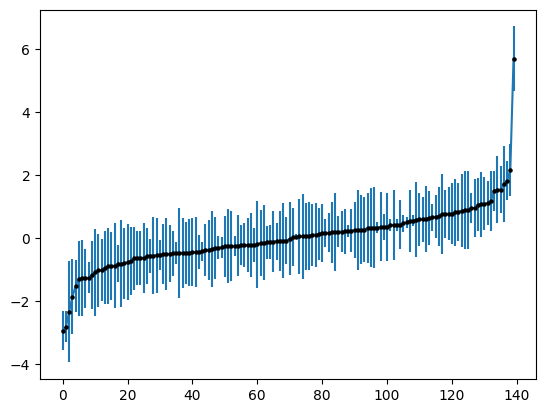

In [68]:
# Optional restart cell: use this only when reopening after taxonomy labelling.
import arviz as az
import birdman.visualization as viz
inference = az.from_netcdf(INFERENCE_LABELED_FILE)
# sanity peek
print(inference.posterior["feature"].values[:10])


# In[ ]:


ax = viz.plot_parameter_estimates(
    inference,
    parameter="beta_var",
    coords={"covariate": "Diet[T.HC]"},
)

In [69]:
# Inspect first again
print(inference.posterior["beta_var"].dims, inference.posterior["beta_var"].shape)

('chain', 'draw', 'covariate', 'feature') (4, 500, 14, 140)


In [70]:
summ = az.summary(
    inference,
    var_names=["beta_var"],
    coords={"covariate": "Diet[T.HC]"}
)
significant_asvs = summ[
    (summ["hdi_3%"] > 0) | (summ["hdi_97%"] < 0)
]
print(significant_asvs)

                                               mean     sd  hdi_3%  hdi_97%  \
beta_var[ASV_85 | g__Staphylococcus]         -1.259  0.501  -2.283   -0.415   
beta_var[ASV_484 | g__Malacoplasma]           0.422  0.192   0.058    0.779   
beta_var[ASV_718 | g__Peptostreptococcus]     0.955  0.487   0.040    1.857   
beta_var[ASV_1587 | g__Malacoplasma]          0.335  0.176   0.026    0.671   
beta_var[ASV_1650 | g__Staphylococcus]       -2.824  0.494  -3.818   -1.953   
beta_var[ASV_1802 | g__Photobacterium]        1.824  0.616   0.592    2.872   
beta_var[ASV_2046 | g__Malacoplasma]          0.412  0.183   0.041    0.729   
beta_var[ASV_2316 | g__Peptoniphilus]         2.172  0.827   0.660    3.766   
beta_var[ASV_2334 | g__Malacoplasma]          0.496  0.164   0.213    0.823   
beta_var[ASV_2413 | g__Companilactobacillus]  1.490  0.642   0.213    2.627   
beta_var[ASV_2718 | g__Lentilactobacillus]    1.541  0.747   0.112    2.822   
beta_var[ASV_2862 | g__Malacoplasma]          0.549 

In [71]:
import arviz as az

# Get a tidy summary for all covariates
az.summary(
    inference, 
    var_names=["beta_var"],       # or whatever your coefficient var is named
    coords={"covariate": [
        "Diet[T.HC]",
        "Day[T.day_02]", "Day[T.day_03]", "Day[T.day_04]", 
        "Day[T.day_10]", "Day[T.day_15]", "Day[T.day_22]",
        "Diet[T.HC]:Day[T.day_02]", "Diet[T.HC]:Day[T.day_03]",
        "Diet[T.HC]:Day[T.day_04]", "Diet[T.HC]:Day[T.day_10]",
        "Diet[T.HC]:Day[T.day_15]", "Diet[T.HC]:Day[T.day_22]"
    ]}
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta_var[Diet[T.HC], ASV_1846 | g__Malacoplasma]",0.037,0.081,-0.114,0.195,0.002,0.002,1635.0,1511.0,1.00
"beta_var[Diet[T.HC], ASV_48 | g__Paracoccus]",0.628,0.864,-0.995,2.188,0.021,0.016,1626.0,1802.0,1.00
"beta_var[Diet[T.HC], ASV_85 | g__Staphylococcus]",-1.259,0.501,-2.283,-0.415,0.018,0.011,807.0,1076.0,1.01
"beta_var[Diet[T.HC], ASV_86 | g__Clostridium]",0.825,0.913,-0.757,2.675,0.025,0.015,1336.0,1808.0,1.01
"beta_var[Diet[T.HC], ASV_186 | g__Stenotrophomonas]",-2.343,1.610,-5.437,0.558,0.034,0.033,2268.0,1566.0,1.00
...,...,...,...,...,...,...,...,...,...
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3155 | c__Gracilibacteria]",0.547,1.571,-2.341,3.597,0.031,0.036,2505.0,1669.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3184 | f__Comamonadaceae]",-0.433,1.740,-3.537,2.843,0.033,0.034,2695.0,1509.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3212 | g__Rhizobium]",-0.402,1.132,-2.486,1.690,0.028,0.023,1649.0,1379.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3234 | g__Lawsonella]",0.442,0.831,-1.140,1.955,0.026,0.018,1032.0,1489.0,1.00


In [73]:
import xarray as xr
import arviz as az

# Posterior for slopes (p-1 covariates) — excludes the Intercept
post_x = inference.posterior["beta_var"]

def sel(term):
    # term must match exactly a label in post_x.coords["covariate"]
    return post_x.sel(covariate=term).reset_coords(drop=True)

days = ["day_01","day_02","day_03","day_04","day_10","day_15","day_22"]

# Baseline contrast (HC - NC) at day_01: just the HC main effect (NC is reference)
delta_base = sel("Diet[T.HC]")

# Contrasts for other days: HC main effect + HC:Day interaction
deltas = {"day_01": delta_base}
for d in days[1:]:
    inter_term = f"Diet[T.HC]:Day[T.{d}]"
    deltas[d] = delta_base + sel(inter_term)

# Stack contrasts over days -> dims: (chain, draw, feature, day)
delta_all = xr.concat([deltas[d] for d in days], dim="day").assign_coords(day=days)

# Summarize (mean, sd, R-hat, ESS, 95% HDI)
summary = az.summary(delta_all, hdi_prob=0.95)
print(summary)

                                                  mean     sd  hdi_2.5%  \
beta_var[day_01, ASV_1846 | g__Malacoplasma]     0.037  0.081    -0.114   
beta_var[day_01, ASV_48 | g__Paracoccus]         0.628  0.864    -1.036   
beta_var[day_01, ASV_85 | g__Staphylococcus]    -1.259  0.501    -2.328   
beta_var[day_01, ASV_86 | g__Clostridium]        0.825  0.913    -0.891   
beta_var[day_01, ASV_186 | g__Stenotrophomonas] -2.343  1.610    -5.521   
...                                                ...    ...       ...   
beta_var[day_22, ASV_3155 | c__Gracilibacteria] -0.480  1.455    -3.474   
beta_var[day_22, ASV_3184 | f__Comamonadaceae]  -0.328  1.697    -3.743   
beta_var[day_22, ASV_3212 | g__Rhizobium]       -0.194  0.987    -2.033   
beta_var[day_22, ASV_3234 | g__Lawsonella]       0.326  0.671    -1.033   
beta_var[day_22, ASV_3258 | g__Staphylococcus]  -8.423  1.618   -11.713   

                                                 hdi_97.5%  mcse_mean  \
beta_var[day_01, ASV_1846 

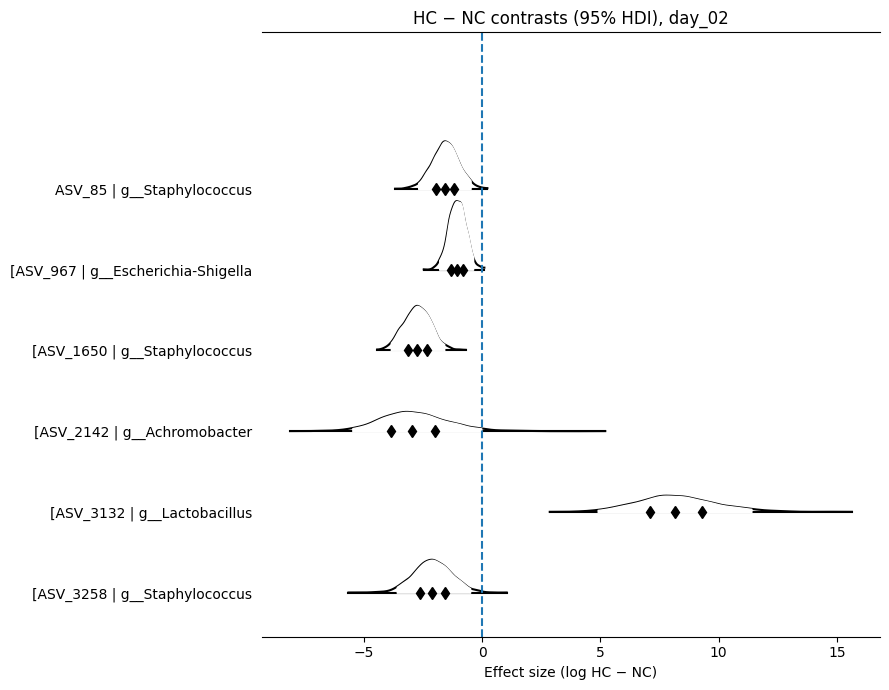

In [74]:
import re
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

day = "day_02"

# summarize contrasts for this day
summ = az.summary(delta_all.sel(day=day), hdi_prob=0.95).rename(columns={"mean":"mean_logFC"})

# keep only HDIs that exclude 0
sig = summ[(summ["hdi_2.5%"] > 0) | (summ["hdi_97.5%"] < 0)].copy()

# extract the feature labels inside brackets
feat_idx = delta_all.coords["feature"].to_index()
sig_features = []
for s in sig.index.astype(str):
    m = re.search(r"\[(.*)\]", s)  # text inside [...]
    if m:
        label = m.group(1)
        if label in feat_idx:
            sig_features.append(label)

if not sig_features:
    raise ValueError("No matching features found after parsing labels. Inspect `summ.index[:5]`.")

# forest plot for those features
to_plot = delta_all.sel(day=day, feature=sig_features).rename("contrast")  # avoid 'beta_x' prefix
axes = az.plot_forest(to_plot,
                      kind='ridgeplot',
                      ridgeplot_truncate=False,
                      ridgeplot_quantiles=[.25, .5, .75],
                      ridgeplot_overlap=0.7,
                      colors='white',
                      figsize=(9, 7),
                      combined=True,
                      hdi_prob=0.95)

# --- put the label-fix RIGHT HERE ---
ax = np.atleast_1d(axes).ravel()[0]
curr = [t.get_text() for t in ax.get_yticklabels()]
# remove the var prefix before '[' and the trailing ']'
clean = [re.sub(r'^[^\[]+\[|\]$', '', s) for s in curr]
# optional: shorten to just ASV ID
# clean = [c.split(" | ", 1)[0] for c in clean]
ax.set_yticklabels(clean)

plt.axvline(0, linestyle="--")
plt.xlabel("Effect size (log HC − NC)")
plt.title(f"HC − NC contrasts (95% HDI), {day}")
plt.tight_layout()
plt.show()

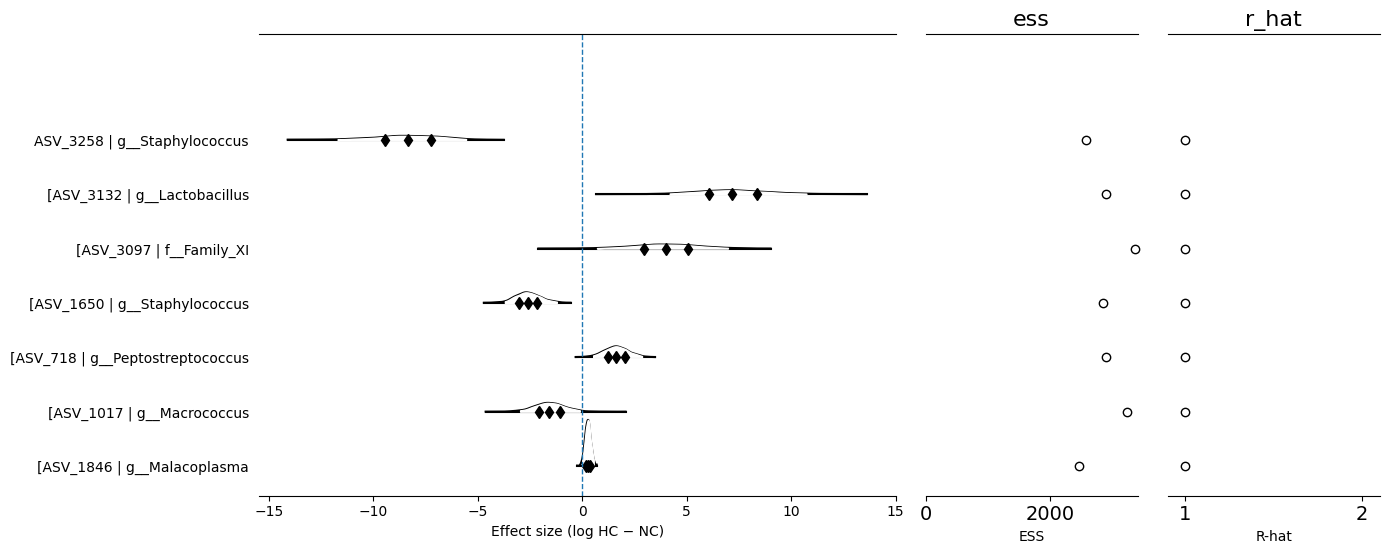

In [75]:
import re
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
day = "day_22"
hdi_prob = 0.95          # set to 0.975 if you want stricter intervals
kind = "ridgeplot"       # "ridgeplot" for ridges, anything else for bar-style
top_n = 40               # None for all, or limit to top effects
ridge_kwargs = dict(     # only used when kind == "ridgeplot"
    ridgeplot_truncate=False,
    ridgeplot_quantiles=[0.25, 0.5, 0.75],   # median line only; use [.25,.5,.75] if you like
    ridgeplot_overlap=0.7,
    colors='white'
)

# ---------- 1) Summarize contrasts for this day ----------
summ = az.summary(delta_all.sel(day=day), hdi_prob=hdi_prob).rename(columns={"mean":"mean_logFC"})

# find the two HDI columns (works for 2.5/97.5 or any)
hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
if len(hdi_cols) < 2:
    raise RuntimeError(f"HDI columns not found in summary: {summ.columns.tolist()}")

# sort by percentile value (e.g., ['hdi_2.5%', 'hdi_97.5%'])
low_col, high_col = sorted(hdi_cols, key=lambda c: float(c.split("_")[1].strip("%")))

# keep only HDIs that exclude 0
sig = summ[(summ[low_col] > 0) | (summ[high_col] < 0)].copy()
if sig.empty:
    raise ValueError(f"No ASVs with {int(hdi_prob*100)}% HDI excluding 0 for {day}.")

# order by absolute effect size and optionally limit
sig["abs_effect"] = sig["mean_logFC"].abs()
sig = sig.sort_values("abs_effect", ascending=False)
if top_n is not None and len(sig) > top_n:
    sig = sig.iloc[:top_n]

# ---------- 2) Parse feature labels from the index ----------
feat_idx = delta_all.coords["feature"].to_index()
sig_features = []
for s in sig.index.astype(str):
    m = re.search(r"\[(.*)\]", s)  # grabs text inside [...]
    if m:
        label = m.group(1)
        if label in feat_idx:
            sig_features.append(label)

if not sig_features:
    raise ValueError("Parsed 0 matching features. Inspect `summ.index[:5]` to see labels.")

# ---------- 3) Forest / ridge plot (CALL ONCE) ----------
to_plot = delta_all.sel(day=day, feature=sig_features).rename("contrast")  # stay on log scale

plt.close("all")  # ensure a fresh figure
plot_kwargs = dict(combined=True, hdi_prob=hdi_prob, ess=True, r_hat=True)

if kind == "ridgeplot":
    axes = az.plot_forest(to_plot, kind="ridgeplot", **plot_kwargs, **ridge_kwargs)
else:
    axes = az.plot_forest(to_plot, **plot_kwargs)

axes_arr = np.atleast_1d(axes).ravel()

# 1) label + zero line ONLY on the main (leftmost) axis
main_ax = axes_arr[0]
main_ax.axvline(0, linestyle="--", linewidth=1)
main_ax.set_xlabel("Effect size (log HC − NC)")

# 2) give sensible labels to the metric panels (if present)
if len(axes_arr) >= 2:
    axes_arr[1].set_xlabel("ESS")
if len(axes_arr) >= 3:
    axes_arr[2].set_xlabel("R-hat")

# 3) clean the first y-tick prefix on the main axis
curr = [t.get_text() for t in main_ax.get_yticklabels()]
if curr:
    clean = [re.sub(r'^[^\[]+\[|\]$', '', s) for s in curr]  # remove 'contrast[' ... ']'
    # optional shorter labels: clean = [c.split(" | ", 1)[0] for c in clean]
    main_ax.set_yticklabels(clean)

plt.tight_layout()
plt.show()